# Generic ETC Cross-Validation

## Objectif

Ce notebook valide la précision de l'**ETC générique** (Exposure Time Calculator) en le comparant avec des outils de référence établis dans la communauté astronomique.

## Méthodologie de Validation

Nous comparons **deux approches** pour le calcul du SNR (Signal-to-Noise Ratio) :

### 1. **Generic ETC** (notre implémentation)
- Classe `Observation` dans `notebooks/Observation.py`
- Modélise toutes les sources de bruit : photon noise, dark current, read noise, CIC, cosmic rays
- Support EMCCD avec gain et excess noise factor
- Pertes d'ouverture (slit/fiber losses) via PSF
- Résolution spectrale prise en compte

### 2. **Astropy SNR** (référence validée)
- Fonction `astropy.stats.signal_to_noise_oir_ccd()`
- Fonction standard bien testée dans la communauté
- Calcule le SNR pour CCD optical/IR
- **Limitations** : 
  - ❌ Pas de support EMCCD (EM gain, CIC, smearing)
  - ❌ Pas de cosmic ray losses
  - ⚠️ Pas de résolution spectrale explicite (on calcule `npix` manuellement)

## Paramètres Comparés

| Paramètre | Generic ETC | Astropy SNR | Unités |
|-----------|-------------|-------------|--------|
| **Signal source** | `Signal` | `source_eps` | erg/cm²/s/arcsec²/Å → e⁻/s |
| **Sky background** | `Sky` | `sky_eps` | erg/cm²/s/arcsec²/Å → e⁻/s/pix |
| **Dark current** | `Dark_current` | `dark_eps` | e⁻/pix/hour → e⁻/s/pix |
| **Read noise** | `RN` | `rd` | e⁻/pix |
| **Temps d'exposition** | `exposure_time` | `t` | secondes |
| **Nombre de pixels** | calculé via `elem_size` | `npix` | pixels |
| **Throughput total** | `Throughput × QE × Atmosphere` | appliqué à `source_eps` | 0-1 |
| **CIC (EMCCD)** | ✅ `CIC_charge` | ❌ non supporté | e⁻/exp |
| **EM gain** | ✅ `EM_gain` | ❌ non supporté | e⁻/e⁻ |
| **Cosmic rays** | ✅ `cosmic_ray_loss_per_sec` | ❌ non supporté | /sec |
| **PSF losses** | ✅ `flux_fraction` | ❌ non supporté | 0-1 |

## Stratégie

**Phase 1** : Test sur détecteur **simple** (pas d'EMCCD)
- Instrument : GALEX FUV ou UVEX (MCP/CMOS, EM_gain=1)
- Validation : Generic ETC vs Astropy SNR
- Critère : Accord ±10-15%

**Phase 2** : Test sur EMCCD (FIREBall-2)
- Astropy ne supportant pas EMCCD, on comparera uniquement la partie "signal"
- Ou on désactivera EM_gain dans Generic ETC pour comparer

**Phase 3** : Analyse des écarts
- Identifier où les différences proviennent
- Tester la partie spectro (résolution, npix)

## Installation

```bash
pip install astropy numpy matplotlib pandas
```

---

**Auteur** : Vincent  
**Date** : Novembre 2024  
**Notebook** : `/Users/Vincent/Github/generic-etc/test/cross-validation/ETC_cross_validation.ipynb`


---

# Setup & Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sys
from pathlib import Path

# Add parent directory to path to import Observation class
sys.path.insert(0, str(Path.cwd().parent.parent / 'notebooks'))

# Import Generic ETC
from Observation import Observation, load_instruments

# Import Astropy SNR function
try:
    from astropy.stats import signal_to_noise_oir_ccd
    ASTROPY_SNR_AVAILABLE = True
    print("✓ astropy.stats.signal_to_noise_oir_ccd available")
except ImportError:
    ASTROPY_SNR_AVAILABLE = False
    print("⚠ astropy.stats not available. Install with: pip install astropy")

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Imports successful")

✓ astropy.stats.signal_to_noise_oir_ccd available
✓ Imports successful


In [2]:
# Load instrument database
instruments, database = load_instruments()

# Display available instruments
print(f"Available instruments ({len(instruments.colnames)-3}):")
for i, name in enumerate(instruments.colnames[3:], 1):
    print(f"  {i:2d}. {name}")

Available instruments (48):
   1. SCWI SPEC
   2. SCWI EMCCD
   3. SCWI Skipper
   4. SCWI CMOS
   5. SCWI MCP
   6. SCWI MIN REQ
   7. SCWI PERF
   8. ISTOS
DEEP
   9. FIREBall-2 2025
  10. FIREBall-2 2018
  11. FIREBall-1
  12. UVEX FUV
  13. UVEX NUV
  14. ASPERA
  15. JUNO UVS
  16. GALEX FUV
  17. GALEX NUV
  18. LUMOS
  19. CASTOR DMD
  20. CETUS
  21. KCWI blue
  22. KCWI red
  23. Blue MUSE
  24. NIRSPEC
  25. ELT Harmony
  26. MUSE wide
  27. MUSE narrow
  28. NISP
  29. SPHERE IRDIS
  30. SPHEREx
  31. tREXS
  32. POLLUX
  33. ARAGO
  34. CASSTOR
  35. LUMOS-MOS
  36. LUMOS-POINT
  37. LUMOS-IFS
  38. HST-COS
  39. HST-STIS
  40. SUMIRE PFS Blue
  41. VLT MOONS
  42. MOSAIC
  43. EUCLID vis
  44. MESSIER nuv
  45. UVEX fuv
  46. UVEX nuv
  47. GALEX fuv
  48. GALEX nuv


---

# 1. Astropy SNR Function (Référence)

Utilisation de la fonction validée `astropy.stats.signal_to_noise_oir_ccd()`

**Documentation** : https://docs.astropy.org/en/stable/api/astropy.stats.signal_to_noise_oir_ccd.html

**Paramètres** :
- `t` : temps d'exposition (s)
- `source_eps` : taux d'électrons de la source/sec dans l'ouverture (e⁻/s)
- `sky_eps` : taux d'électrons du ciel/sec/pixel (e⁻/s/pix)
- `dark_eps` : dark current (e⁻/s/pix)
- `rd` : read noise (e⁻)
- `npix` : nombre de pixels dans l'ouverture
- `gain` : gain CCD (défaut=1.0)

**Formule** :
$$
\text{SNR} = \frac{t \cdot \text{source\_eps}}{\sqrt{t \cdot (\text{source\_eps} + \text{npix} \cdot (\text{sky\_eps} + \text{dark\_eps})) + \text{npix} \cdot \text{rd}^2}}
$$

In [3]:
def calculate_SNR_astropy(signal_flux, sky_flux, collecting_area, throughput, QE, atmosphere,
                          pixel_scale, dispersion, wavelength_nm, exposure_time,
                          dark_current, read_noise, n_pixels=1):
    """
    Calculate SNR using astropy.stats.signal_to_noise_oir_ccd().
    
    Converts Generic ETC parameters to Astropy format.
    
    Parameters
    ----------
    signal_flux : float
        Source flux in erg/cm²/s/arcsec²/Å
    sky_flux : float
        Sky background flux in erg/cm²/s/arcsec²/Å
    collecting_area : float
        Telescope collecting area in m²
    throughput : float
        Instrument throughput (0-1), excluding QE and atmosphere
    QE : float
        Quantum efficiency (0-1)
    atmosphere : float
        Atmospheric transmission (0-1)
    pixel_scale : float
        Pixel scale in arcsec/pixel
    dispersion : float
        Spectral dispersion in Å/pixel
    wavelength_nm : float
        Observation wavelength in nm
    exposure_time : float
        Exposure time in seconds
    dark_current : float
        Dark current in e⁻/pixel/hour
    read_noise : float
        Read noise in e⁻/pixel
    n_pixels : int or float
        Number of pixels in aperture (1 for per-pixel SNR, elem_size for per-res-elem)
        
    Returns
    -------
    dict with 'SNR' and intermediate values
    """
    # Convert flux (erg/cm²/s/arcsec²/Å) to photons/cm²/s/arcsec²/Å
    # E_photon = h * c / λ = 1.986e-8 [erg·Å] / λ[nm]
    E_photon = 1.986e-8 / wavelength_nm  # erg
    
    signal_photons_rate = signal_flux / E_photon  # photons/cm²/s/arcsec²/Å
    sky_photons_rate = sky_flux / E_photon        # photons/cm²/s/arcsec²/Å
    
    # Convert to electrons using telescope + instrument parameters
    collecting_area_cm2 = collecting_area * 1e4  # m² → cm²
    pixel_area_arcsec2 = pixel_scale**2          # arcsec²
    wavelength_range = dispersion                 # Å/pixel
    total_throughput = throughput * QE * atmosphere
    
    # source_eps: e⁻/s in aperture (summed over n_pixels)
    source_eps_per_pix = (signal_photons_rate * 
                          collecting_area_cm2 * 
                          pixel_area_arcsec2 * 
                          wavelength_range * 
                          total_throughput)
    source_eps = source_eps_per_pix * n_pixels  # Total in aperture
    
    # sky_eps: e⁻/s/pixel
    sky_eps = (sky_photons_rate * 
               collecting_area_cm2 * 
               pixel_area_arcsec2 * 
               wavelength_range * 
               total_throughput)
    
    # dark_eps: e⁻/s/pixel (convert from e⁻/pix/hour)
    dark_eps = dark_current / 3600.0
    
    # rd: read noise in e⁻ (already in correct units)
    rd = read_noise
    
    # Call Astropy function
    if not ASTROPY_SNR_AVAILABLE:
        return {'SNR': np.nan, 'error': 'Astropy not available'}
    
    snr = signal_to_noise_oir_ccd(
        t=exposure_time,
        source_eps=source_eps,
        sky_eps=sky_eps,
        dark_eps=dark_eps,
        rd=rd,
        npix=n_pixels,
        gain=1.0  # We work in electrons directly
    )
    
    return {
        'SNR': snr,
        'source_eps': source_eps,
        'sky_eps': sky_eps,
        'dark_eps': dark_eps,
        'rd': rd,
        'npix': n_pixels
    }

print("✓ Astropy SNR wrapper function defined")

✓ Astropy SNR wrapper function defined


---

# 2. Test Case 1 : Détecteur Simple (GALEX FUV)

Commençons avec un cas simple :
- **Instrument** : GALEX FUV (MCP detector, EM_gain=1, pas de CIC)
- **Configuration** : Conditions spatiales, pas d'atmosphère
- **Test** : SNR vs temps d'exposition
- **Mode** : SNR per pixel (`npix=1`)

Ceci permet de valider la logique de base avant d'ajouter de la complexité.

In [4]:
# Extract GALEX FUV parameters from instruments database
instrument_name = "GALEX FUV"

# Get instrument parameters
idx = list(instruments.colnames).index(instrument_name)
params = {}
for i, charact in enumerate(instruments['Charact.']):
    if charact and not isinstance(charact, np.ma.core.MaskedConstant):
        value = instruments[instrument_name][i]
        if not isinstance(value, np.ma.core.MaskedConstant):
            params[charact] = value

# Display key parameters
print(f"\n{'='*60}")
print(f"Instrument: {instrument_name}")
print(f"{'='*60}")
print(f"\nTelescope:")
print(f"  Collecting area: {params.get('Collecting_area', 'N/A')} m²")
print(f"  Altitude: {params.get('Altitude', 'N/A')} km")
print(f"  Atmosphere transmission: {params.get('Atmosphere', 'N/A')}")
print(f"\nInstrument:")
print(f"  Wavelength: {params.get('wavelength', 'N/A')} nm")
print(f"  Throughput: {params.get('Throughput', 'N/A')}")
print(f"  Pixel scale: {params.get('pixel_scale', 'N/A')} arcsec/pix")
print(f"  Dispersion: {params.get('dispersion', 'N/A')} Å/pix")
print(f"  Spectral resolution: {params.get('Spectral_resolution', 'N/A')}")
print(f"\nDetector:")
print(f"  Type: {params.get('Detector_type', 'N/A')}")
print(f"  QE: {params.get('QE', 'N/A')}")
print(f"  Read noise: {params.get('RN', 'N/A')} e⁻/pix")
print(f"  Dark current: {params.get('Dark_current', 'N/A')} e⁻/pix/hour")
print(f"  EM gain: {params.get('EM_gain', 'N/A')}")
print(f"  CIC: {params.get('CIC_charge', 'N/A')} e⁻/exp")
print(f"\nObservation:")
print(f"  Signal: {params.get('Signal', 'N/A')} erg/cm²/s/arcsec²/Å")
print(f"  Sky: {params.get('Sky', 'N/A')} erg/cm²/s/arcsec²/Å")
print(f"  Exposure time: {params.get('exposure_time', 'N/A')} s")
print(f"{'='*60}\n")


Instrument: GALEX FUV

Telescope:
  Altitude: 1000.0 km
  Atmosphere transmission: 1.0

Instrument:
  Wavelength: 152.8 nm
  Throughput: 0.16
  Pixel scale: 1.5 arcsec/pix
  Dispersion: 2.5 Å/pix
  Spectral resolution: 200.0

Detector:
  Type: nan
  QE: 0.12
  Read noise: 0.0 e⁻/pix
  Dark current: 0.049 e⁻/pix/hour
  EM gain: 1.0
  CIC: 0.0 e⁻/exp

Observation:
  Signal: 5.6e-19 erg/cm²/s/arcsec²/Å
  Sky: 1.53e-19 erg/cm²/s/arcsec²/Å
  Exposure time: 1000.0 s



Calculating SNR for different exposure times...
✓ Calculations complete



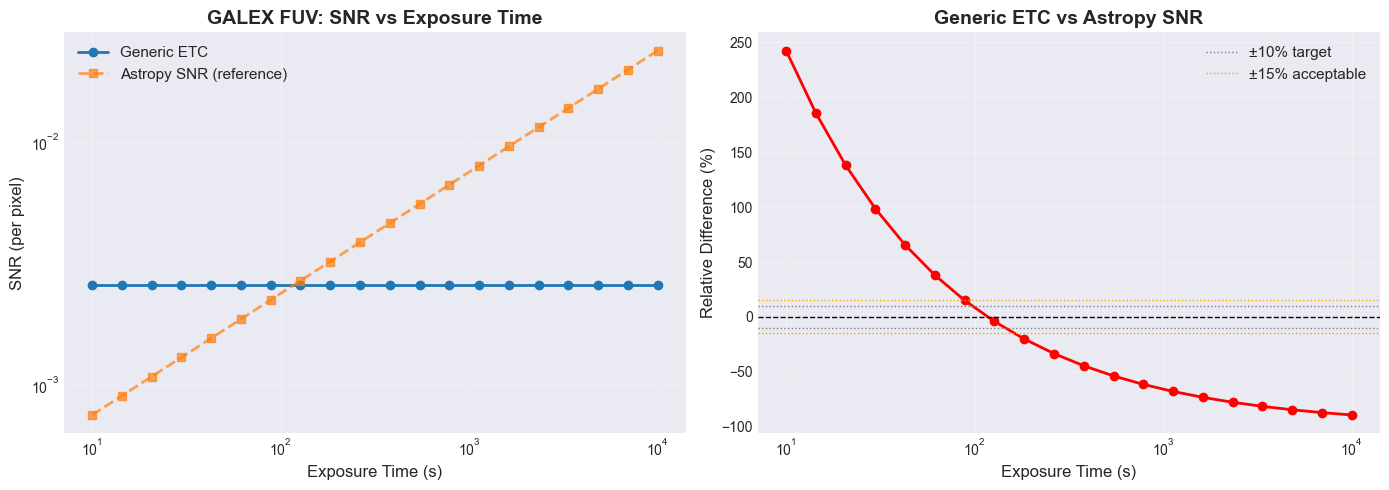


Validation Statistics: GALEX FUV
Mean relative difference: 0.29%
Std relative difference: 95.72%
Max relative difference: 242.42%
Min relative difference: -89.17%

Target: ±10-15%
Result: ✗ FAILED (> 15%)



In [6]:
# Test: SNR vs Exposure Time
exposure_times = np.logspace(1, 4, 20)  # 10s to 10,000s

# Arrays to store results
snr_generic = []
snr_astropy = []

# Common parameters
signal_flux = params['Signal']
sky_flux = params['Sky']
collecting_area = params['Collecting_area']
throughput = params['Throughput']
QE = params['QE']
atmosphere = params['Atmosphere']
pixel_scale = params['pixel_scale']
dispersion = params['dispersion']
wavelength_nm = params['wavelength']
dark_current = params['Dark_current']
read_noise = params['RN']

# Calculate SNR for each exposure time
print("Calculating SNR for different exposure times...")
for t_exp in exposure_times:
    # 1. Generic ETC
    obs_generic = Observation(
        instruments=instruments,
        instrument=instrument_name,
        exposure_time=t_exp,
        SNR_res="per pix",
        IFS=False,
        test=False
    )
    snr_generic.append(obs_generic.SNR[obs_generic.i])
    
    # 2. Astropy SNR
    result_astropy = calculate_SNR_astropy(
        signal_flux=signal_flux,
        sky_flux=sky_flux,
        collecting_area=collecting_area,
        throughput=throughput,
        QE=QE,
        atmosphere=atmosphere,
        pixel_scale=pixel_scale,
        dispersion=dispersion,
        wavelength_nm=wavelength_nm,
        exposure_time=t_exp,
        dark_current=dark_current,
        read_noise=read_noise,
        n_pixels=1  # Per pixel mode
    )
    snr_astropy.append(result_astropy['SNR'])

# Convert to arrays
snr_generic = np.array(snr_generic)
snr_astropy = np.array(snr_astropy)

# Calculate relative difference
relative_diff = 100 * (snr_generic - snr_astropy) / snr_astropy

print("✓ Calculations complete\n")

# Plot results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# SNR vs Exposure Time
ax1.loglog(exposure_times, snr_generic, 'o-', label='Generic ETC', linewidth=2, markersize=6)
ax1.loglog(exposure_times, snr_astropy, 's--', label='Astropy SNR (reference)', linewidth=2, alpha=0.7, markersize=6)
ax1.set_xlabel('Exposure Time (s)', fontsize=12)
ax1.set_ylabel('SNR (per pixel)', fontsize=12)
ax1.set_title(f'{instrument_name}: SNR vs Exposure Time', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Relative difference
ax2.semilogx(exposure_times, relative_diff, 'o-', color='red', linewidth=2, markersize=6)
ax2.axhline(0, color='black', linestyle='--', linewidth=1)
ax2.axhline(10, color='gray', linestyle=':', linewidth=1, label='±10% target')
ax2.axhline(-10, color='gray', linestyle=':', linewidth=1)
ax2.axhline(15, color='orange', linestyle=':', linewidth=1, label='±15% acceptable')
ax2.axhline(-15, color='orange', linestyle=':', linewidth=1)
ax2.set_xlabel('Exposure Time (s)', fontsize=12)
ax2.set_ylabel('Relative Difference (%)', fontsize=12)
ax2.set_title('Generic ETC vs Astropy SNR', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics
print(f"\n{'='*60}")
print(f"Validation Statistics: {instrument_name}")
print(f"{'='*60}")
print(f"Mean relative difference: {np.mean(relative_diff):.2f}%")
print(f"Std relative difference: {np.std(relative_diff):.2f}%")
print(f"Max relative difference: {np.max(np.abs(relative_diff)):.2f}%")
print(f"Min relative difference: {np.min(relative_diff):.2f}%")
print(f"\nTarget: ±10-15%")
if np.max(np.abs(relative_diff)) < 10:
    print(f"Result: ✓✓ EXCELLENT (< 10%)")
elif np.max(np.abs(relative_diff)) < 15:
    print(f"Result: ✓ PASSED (< 15%)")
else:
    print(f"Result: ✗ FAILED (> 15%)")
print(f"{'='*60}\n")

---

# 3. Analyse Détaillée (Debug)

Si les écarts sont importants, analysons les valeurs intermédiaires pour identifier la source du problème.

In [14]:
# Pick one exposure time for detailed analysis
t_test = 1000  # seconds

print(f"\n{'='*60}")
print(f"Detailed Analysis for t_exp = {t_test} s")
print(f"{'='*60}\n")

# Generic ETC
obs_test = Observation(
    instruments=instruments,
    instrument=instrument_name,
    exposure_time=t_test,
    IFS=False,
    SNR_res="per pix",
    test=False
)

print("Generic ETC Results:")
print(f"  SNR: {obs_test.SNR[obs_test.i]:.4f}")
print(f"  Signal (e⁻): {obs_test.Signal_el[obs_test.i]:.4f}")
print(f"  Sky noise (e⁻): {obs_test.sky[obs_test.i]:.4f}")
print(f"  Dark noise (e⁻): {obs_test.Dark_current_f[obs_test.i]:.4f}")
# print(f"  Read noise (e⁻): {obs_test.RN_final:.4f}")
print(f"  Total noise (e⁻): {obs_test.Total_noise_final[obs_test.i]:.4f}")
# print(f"  Number of pixels: {obs_test.number_pixels_used[obs_test.i]:.2f}")
print(f"  Number of pixels: {obs_test.number_pixels_used:.2f}")

# Astropy SNR
result_test = calculate_SNR_astropy(
    signal_flux=signal_flux,
    sky_flux=sky_flux,
    collecting_area=collecting_area,
    throughput=throughput,
    QE=QE,
    atmosphere=atmosphere,
    pixel_scale=pixel_scale,
    dispersion=dispersion,
    wavelength_nm=wavelength_nm,
    exposure_time=t_test,
    dark_current=dark_current,
    read_noise=read_noise,
    n_pixels=1
)

print(f"\nAstropy SNR Results:")
print(f"  SNR: {result_test['SNR']:.4f}")
print(f"  source_eps (e⁻/s): {result_test['source_eps']:.6f}")
print(f"  sky_eps (e⁻/s/pix): {result_test['sky_eps']:.6f}")
print(f"  dark_eps (e⁻/s/pix): {result_test['dark_eps']:.6f}")
print(f"  rd (e⁻): {result_test['rd']:.4f}")
print(f"  npix: {result_test['npix']:.2f}")

# Calculate expected values from Astropy rates
signal_total = result_test['source_eps'] * t_test
sky_total = result_test['sky_eps'] * t_test * result_test['npix']
dark_total = result_test['dark_eps'] * t_test * result_test['npix']
read_total = result_test['rd'] * np.sqrt(result_test['npix'])
noise_total = np.sqrt(signal_total + sky_total + dark_total + read_total**2)

print(f"\nAstropy Derived Values (for comparison):")
print(f"  Signal total (e⁻): {signal_total:.4f}")
print(f"  Sky total (e⁻): {sky_total:.4f}")
print(f"  Dark total (e⁻): {dark_total:.4f}")
print(f"  Read total (e⁻): {read_total:.4f}")
print(f"  Total noise (e⁻): {noise_total:.4f}")

print(f"\n{'='*60}\n")


Detailed Analysis for t_exp = 1000 s

Generic ETC Results:
  SNR: 0.0026
  Signal (e⁻): 0.0001
  Sky noise (e⁻): 0.1409
  Dark noise (e⁻): 0.0136
  Total noise (e⁻): 7.6863
  Number of pixels: 1.00

Astropy SNR Results:
  SNR: 0.0075
  source_eps (e⁻/s): 0.000001
  sky_eps (e⁻/s/pix): 0.000000
  dark_eps (e⁻/s/pix): 0.000014
  rd (e⁻): 0.0000
  npix: 1.00

Astropy Derived Values (for comparison):
  Signal total (e⁻): 0.0009
  Sky total (e⁻): 0.0002
  Dark total (e⁻): 0.0136
  Read total (e⁻): 0.0000
  Total noise (e⁻): 0.1215




---

# Prochaines Étapes

## Selon les résultats :

### Si accord < 15% ✓
1. **Tester d'autres instruments** (UVEX, SCWI)
2. **Tester SNR per resolution element** (`npix > 1`)
3. **Comparer avec votre ancien ETC** (`spectro-imager-etc`)

### Si écarts > 15% ✗
1. **Analyser la section Debug** ci-dessus
2. **Vérifier** :
   - Conversion flux → électrons (énergie photon)
   - Pertes d'ouverture dans Generic ETC (`flux_fraction`)
   - Cosmic ray losses
   - Différence dans le calcul du nombre de pixels

## Limitations actuelles :
- ⚠️ Astropy SNR ne supporte pas EMCCD → tests limités aux détecteurs simples
- ⚠️ Pas de validation de la partie spectro (résolution spectrale, dispersion)
- ⚠️ Pas de test des pertes PSF/slit

---

**Status** : Notebook avec Astropy SNR créé ✓  
**Next** : Exécuter et analyser les résultats


# 4. Fonction de Validation Générale

Fonction pour valider tous les instruments sur plusieurs paramètres.

In [ ]:
import os
from matplotlib.gridspec import GridSpec

def validate_instrument(instrument_name, instruments, output_dir='./images/'):
    """
    Validate Generic ETC against Astropy SNR for a given instrument.
    
    Tests multiple parameters:
    1. Exposure time
    2. Signal flux
    3. Sky background
    4. Read noise
    5. Dark current
    
    Parameters
    ----------
    instrument_name : str
        Name of the instrument to validate
    instruments : astropy.Table
        Instrument database
    output_dir : str
        Directory to save validation plots
        
    Returns
    -------
    dict with validation results
    """
    
    # Create output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)
    
    # Extract instrument parameters
    try:
        idx = list(instruments.colnames).index(instrument_name)
    except ValueError:
        print(f"⚠ Instrument '{instrument_name}' not found")
        return None
    
    params = {}
    for i, charact in enumerate(instruments['Charact.']):
        if charact and not isinstance(charact, np.ma.core.MaskedConstant):
            value = instruments[instrument_name][i]
            if not isinstance(value, np.ma.core.MaskedConstant):
                params[charact] = value
    
    # Check for required parameters
    required_params = ['Signal', 'Sky', 'Collecting_area', 'Throughput', 'QE',
                      'Atmosphere', 'pixel_scale', 'dispersion', 'wavelength',
                      'Dark_current', 'RN']
    missing_params = [p for p in required_params if p not in params]
    if missing_params:
        print(f"⚠ {instrument_name}: Missing parameters {missing_params}")
        return None
    
    # Check if EMCCD (skip if EM_gain > 1, Astropy doesn't support it)
    em_gain = params.get('EM_gain', 1.0)
    if em_gain > 1.0:
        print(f"⚠ {instrument_name}: EMCCD detected (EM_gain={em_gain}), skipping")
        return None
    
    print(f"\n{'='*60}")
    print(f"Validating: {instrument_name}")
    print(f"{'='*60}")
    
    # Common parameters
    signal_flux_nominal = params['Signal']
    sky_flux_nominal = params['Sky']
    collecting_area = params['Collecting_area']
    throughput = params['Throughput']
    QE = params['QE']
    atmosphere = params['Atmosphere']
    pixel_scale = params['pixel_scale']
    dispersion = params['dispersion']
    wavelength_nm = params['wavelength']
    dark_current_nominal = params['Dark_current']
    read_noise_nominal = params['RN']
    exposure_time_nominal = params.get('exposure_time', 1000.0)
    
    # Create figure with 5 subplots (3 rows, 4 cols)
    fig = plt.figure(figsize=(20, 12))
    gs = GridSpec(3, 4, figure=fig, hspace=0.3, wspace=0.3)
    
    results = {}
    
    # -------------------------------------------------------------------
    # Test 1: Exposure Time
    # -------------------------------------------------------------------
    print("  Testing exposure time variation...")
    exposure_times = np.logspace(1, 4, 15)
    snr_generic_exp = []
    snr_astropy_exp = []
    
    for t_exp in exposure_times:
        # Generic ETC
        obs = Observation(
            instruments=instruments,
            instrument=instrument_name,
            exposure_time=t_exp,
            SNR_res="per pix",
            IFS=False,
            test=False
        )
        snr_generic_exp.append(obs.SNR[obs.i])
        
        # Astropy SNR
        result = calculate_SNR_astropy(
            signal_flux=signal_flux_nominal,
            sky_flux=sky_flux_nominal,
            collecting_area=collecting_area,
            throughput=throughput,
            QE=QE,
            atmosphere=atmosphere,
            pixel_scale=pixel_scale,
            dispersion=dispersion,
            wavelength_nm=wavelength_nm,
            exposure_time=t_exp,
            dark_current=dark_current_nominal,
            read_noise=read_noise_nominal,
            n_pixels=1
        )
        snr_astropy_exp.append(result['SNR'])
    
    snr_generic_exp = np.array(snr_generic_exp)
    snr_astropy_exp = np.array(snr_astropy_exp)
    relative_diff_exp = 100 * (snr_generic_exp - snr_astropy_exp) / snr_astropy_exp
    
    # Plot
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.loglog(exposure_times, snr_generic_exp, 'o-', label='Generic ETC', linewidth=2, markersize=4)
    ax1.loglog(exposure_times, snr_astropy_exp, 's--', label='Astropy', linewidth=2, alpha=0.7, markersize=4)
    ax1.set_xlabel('Exposure Time (s)', fontsize=10)
    ax1.set_ylabel('SNR', fontsize=10)
    ax1.set_title('SNR vs Exposure Time', fontsize=11, fontweight='bold')
    ax1.legend(fontsize=9)
    ax1.grid(True, alpha=0.3)
    
    ax2 = fig.add_subplot(gs[1, 0])
    ax2.semilogx(exposure_times, relative_diff_exp, 'o-', color='red', linewidth=2, markersize=4)
    ax2.axhline(0, color='black', linestyle='--', linewidth=1)
    ax2.axhline(15, color='orange', linestyle=':', linewidth=1)
    ax2.axhline(-15, color='orange', linestyle=':', linewidth=1)
    ax2.set_xlabel('Exposure Time (s)', fontsize=10)
    ax2.set_ylabel('Relative Diff (%)', fontsize=10)
    ax2.set_title(f'Max: {np.max(np.abs(relative_diff_exp)):.1f}%', fontsize=10)
    ax2.grid(True, alpha=0.3)
    
    results['exposure_time'] = {
        'mean_diff': np.mean(relative_diff_exp),
        'max_diff': np.max(np.abs(relative_diff_exp)),
        'std_diff': np.std(relative_diff_exp)
    }
    
    # -------------------------------------------------------------------
    # Test 2: Signal Flux
    # -------------------------------------------------------------------
    print("  Testing signal flux variation...")
    signal_factors = np.logspace(-1, 1, 15)  # 0.1x to 10x nominal
    snr_generic_sig = []
    snr_astropy_sig = []
    
    for factor in signal_factors:
        signal_flux = signal_flux_nominal * factor
        
        # Temporarily modify instruments table
        original_signal = instruments[instrument_name][list(instruments['Charact.']).index('Signal')]
        instruments[instrument_name][list(instruments['Charact.']).index('Signal')] = signal_flux
        
        # Generic ETC
        obs = Observation(
            instruments=instruments,
            instrument=instrument_name,
            exposure_time=exposure_time_nominal,
            SNR_res="per pix",
            IFS=False,
            test=False
        )
        snr_generic_sig.append(obs.SNR[obs.i])
        
        # Restore
        instruments[instrument_name][list(instruments['Charact.']).index('Signal')] = original_signal
        
        # Astropy SNR
        result = calculate_SNR_astropy(
            signal_flux=signal_flux,
            sky_flux=sky_flux_nominal,
            collecting_area=collecting_area,
            throughput=throughput,
            QE=QE,
            atmosphere=atmosphere,
            pixel_scale=pixel_scale,
            dispersion=dispersion,
            wavelength_nm=wavelength_nm,
            exposure_time=exposure_time_nominal,
            dark_current=dark_current_nominal,
            read_noise=read_noise_nominal,
            n_pixels=1
        )
        snr_astropy_sig.append(result['SNR'])
    
    snr_generic_sig = np.array(snr_generic_sig)
    snr_astropy_sig = np.array(snr_astropy_sig)
    relative_diff_sig = 100 * (snr_generic_sig - snr_astropy_sig) / snr_astropy_sig
    
    # Plot
    ax3 = fig.add_subplot(gs[0, 1])
    ax3.loglog(signal_factors, snr_generic_sig, 'o-', label='Generic ETC', linewidth=2, markersize=4)
    ax3.loglog(signal_factors, snr_astropy_sig, 's--', label='Astropy', linewidth=2, alpha=0.7, markersize=4)
    ax3.set_xlabel('Signal Factor (×nominal)', fontsize=10)
    ax3.set_ylabel('SNR', fontsize=10)
    ax3.set_title('SNR vs Signal Flux', fontsize=11, fontweight='bold')
    ax3.legend(fontsize=9)
    ax3.grid(True, alpha=0.3)
    
    ax4 = fig.add_subplot(gs[1, 1])
    ax4.semilogx(signal_factors, relative_diff_sig, 'o-', color='red', linewidth=2, markersize=4)
    ax4.axhline(0, color='black', linestyle='--', linewidth=1)
    ax4.axhline(15, color='orange', linestyle=':', linewidth=1)
    ax4.axhline(-15, color='orange', linestyle=':', linewidth=1)
    ax4.set_xlabel('Signal Factor', fontsize=10)
    ax4.set_ylabel('Relative Diff (%)', fontsize=10)
    ax4.set_title(f'Max: {np.max(np.abs(relative_diff_sig)):.1f}%', fontsize=10)
    ax4.grid(True, alpha=0.3)
    
    results['signal_flux'] = {
        'mean_diff': np.mean(relative_diff_sig),
        'max_diff': np.max(np.abs(relative_diff_sig)),
        'std_diff': np.std(relative_diff_sig)
    }
    
    # -------------------------------------------------------------------
    # Test 3: Sky Background
    # -------------------------------------------------------------------
    print("  Testing sky background variation...")
    sky_factors = np.logspace(-1, 1, 15)  # 0.1x to 10x nominal
    snr_generic_sky = []
    snr_astropy_sky = []
    
    for factor in sky_factors:
        sky_flux = sky_flux_nominal * factor
        
        # Temporarily modify instruments table
        original_sky = instruments[instrument_name][list(instruments['Charact.']).index('Sky')]
        instruments[instrument_name][list(instruments['Charact.']).index('Sky')] = sky_flux
        
        # Generic ETC
        obs = Observation(
            instruments=instruments,
            instrument=instrument_name,
            exposure_time=exposure_time_nominal,
            SNR_res="per pix",
            IFS=False,
            test=False
        )
        snr_generic_sky.append(obs.SNR[obs.i])
        
        # Restore
        instruments[instrument_name][list(instruments['Charact.']).index('Sky')] = original_sky
        
        # Astropy SNR
        result = calculate_SNR_astropy(
            signal_flux=signal_flux_nominal,
            sky_flux=sky_flux,
            collecting_area=collecting_area,
            throughput=throughput,
            QE=QE,
            atmosphere=atmosphere,
            pixel_scale=pixel_scale,
            dispersion=dispersion,
            wavelength_nm=wavelength_nm,
            exposure_time=exposure_time_nominal,
            dark_current=dark_current_nominal,
            read_noise=read_noise_nominal,
            n_pixels=1
        )
        snr_astropy_sky.append(result['SNR'])
    
    snr_generic_sky = np.array(snr_generic_sky)
    snr_astropy_sky = np.array(snr_astropy_sky)
    relative_diff_sky = 100 * (snr_generic_sky - snr_astropy_sky) / snr_astropy_sky
    
    # Plot
    ax5 = fig.add_subplot(gs[0, 2])
    ax5.loglog(sky_factors, snr_generic_sky, 'o-', label='Generic ETC', linewidth=2, markersize=4)
    ax5.loglog(sky_factors, snr_astropy_sky, 's--', label='Astropy', linewidth=2, alpha=0.7, markersize=4)
    ax5.set_xlabel('Sky Factor (×nominal)', fontsize=10)
    ax5.set_ylabel('SNR', fontsize=10)
    ax5.set_title('SNR vs Sky Background', fontsize=11, fontweight='bold')
    ax5.legend(fontsize=9)
    ax5.grid(True, alpha=0.3)
    
    ax6 = fig.add_subplot(gs[1, 2])
    ax6.semilogx(sky_factors, relative_diff_sky, 'o-', color='red', linewidth=2, markersize=4)
    ax6.axhline(0, color='black', linestyle='--', linewidth=1)
    ax6.axhline(15, color='orange', linestyle=':', linewidth=1)
    ax6.axhline(-15, color='orange', linestyle=':', linewidth=1)
    ax6.set_xlabel('Sky Factor', fontsize=10)
    ax6.set_ylabel('Relative Diff (%)', fontsize=10)
    ax6.set_title(f'Max: {np.max(np.abs(relative_diff_sky)):.1f}%', fontsize=10)
    ax6.grid(True, alpha=0.3)
    
    results['sky_background'] = {
        'mean_diff': np.mean(relative_diff_sky),
        'max_diff': np.max(np.abs(relative_diff_sky)),
        'std_diff': np.std(relative_diff_sky)
    }
    
    # -------------------------------------------------------------------
    # Test 4: Read Noise
    # -------------------------------------------------------------------
    print("  Testing read noise variation...")
    # Only test if nominal read noise > 0
    if read_noise_nominal > 0.1:
        read_noise_values = np.linspace(0.1, read_noise_nominal * 5, 15)
        snr_generic_rn = []
        snr_astropy_rn = []
        
        for rn in read_noise_values:
            # Temporarily modify instruments table
            original_rn = instruments[instrument_name][list(instruments['Charact.']).index('RN')]
            instruments[instrument_name][list(instruments['Charact.']).index('RN')] = rn
            
            # Generic ETC
            obs = Observation(
                instruments=instruments,
                instrument=instrument_name,
                exposure_time=exposure_time_nominal,
                SNR_res="per pix",
                IFS=False,
                test=False
            )
            snr_generic_rn.append(obs.SNR[obs.i])
            
            # Restore
            instruments[instrument_name][list(instruments['Charact.']).index('RN')] = original_rn
            
            # Astropy SNR
            result = calculate_SNR_astropy(
                signal_flux=signal_flux_nominal,
                sky_flux=sky_flux_nominal,
                collecting_area=collecting_area,
                throughput=throughput,
                QE=QE,
                atmosphere=atmosphere,
                pixel_scale=pixel_scale,
                dispersion=dispersion,
                wavelength_nm=wavelength_nm,
                exposure_time=exposure_time_nominal,
                dark_current=dark_current_nominal,
                read_noise=rn,
                n_pixels=1
            )
            snr_astropy_rn.append(result['SNR'])
        
        snr_generic_rn = np.array(snr_generic_rn)
        snr_astropy_rn = np.array(snr_astropy_rn)
        relative_diff_rn = 100 * (snr_generic_rn - snr_astropy_rn) / snr_astropy_rn
        
        # Plot
        ax7 = fig.add_subplot(gs[0, 3])
        ax7.plot(read_noise_values, snr_generic_rn, 'o-', label='Generic ETC', linewidth=2, markersize=4)
        ax7.plot(read_noise_values, snr_astropy_rn, 's--', label='Astropy', linewidth=2, alpha=0.7, markersize=4)
        ax7.set_xlabel('Read Noise (e⁻)', fontsize=10)
        ax7.set_ylabel('SNR', fontsize=10)
        ax7.set_title('SNR vs Read Noise', fontsize=11, fontweight='bold')
        ax7.legend(fontsize=9)
        ax7.grid(True, alpha=0.3)
        
        ax8 = fig.add_subplot(gs[1, 3])
        ax8.plot(read_noise_values, relative_diff_rn, 'o-', color='red', linewidth=2, markersize=4)
        ax8.axhline(0, color='black', linestyle='--', linewidth=1)
        ax8.axhline(15, color='orange', linestyle=':', linewidth=1)
        ax8.axhline(-15, color='orange', linestyle=':', linewidth=1)
        ax8.set_xlabel('Read Noise (e⁻)', fontsize=10)
        ax8.set_ylabel('Relative Diff (%)', fontsize=10)
        ax8.set_title(f'Max: {np.max(np.abs(relative_diff_rn)):.1f}%', fontsize=10)
        ax8.grid(True, alpha=0.3)
        
        results['read_noise'] = {
            'mean_diff': np.mean(relative_diff_rn),
            'max_diff': np.max(np.abs(relative_diff_rn)),
            'std_diff': np.std(relative_diff_rn)
        }
    else:
        # Skip read noise test
        ax7 = fig.add_subplot(gs[0, 3])
        ax7.text(0.5, 0.5, 'Read Noise ≈ 0\\n(Not tested)',
                ha='center', va='center', fontsize=12, transform=ax7.transAxes)
        ax7.axis('off')
        ax8 = fig.add_subplot(gs[1, 3])
        ax8.axis('off')
        results['read_noise'] = None
    
    # -------------------------------------------------------------------
    # Test 5: Dark Current
    # -------------------------------------------------------------------
    print("  Testing dark current variation...")
    # Only test if nominal dark current > 0
    if dark_current_nominal > 0.01:
        dark_current_values = np.linspace(0.01, dark_current_nominal * 5, 15)
        snr_generic_dc = []
        snr_astropy_dc = []
        
        for dc in dark_current_values:
            # Temporarily modify instruments table
            original_dc = instruments[instrument_name][list(instruments['Charact.']).index('Dark_current')]
            instruments[instrument_name][list(instruments['Charact.']).index('Dark_current')] = dc
            
            # Generic ETC
            obs = Observation(
                instruments=instruments,
                instrument=instrument_name,
                exposure_time=exposure_time_nominal,
                SNR_res="per pix",
                IFS=False,
                test=False
            )
            snr_generic_dc.append(obs.SNR[obs.i])
            
            # Restore
            instruments[instrument_name][list(instruments['Charact.']).index('Dark_current')] = original_dc
            
            # Astropy SNR
            result = calculate_SNR_astropy(
                signal_flux=signal_flux_nominal,
                sky_flux=sky_flux_nominal,
                collecting_area=collecting_area,
                throughput=throughput,
                QE=QE,
                atmosphere=atmosphere,
                pixel_scale=pixel_scale,
                dispersion=dispersion,
                wavelength_nm=wavelength_nm,
                exposure_time=exposure_time_nominal,
                dark_current=dc,
                read_noise=read_noise_nominal,
                n_pixels=1
            )
            snr_astropy_dc.append(result['SNR'])
        
        snr_generic_dc = np.array(snr_generic_dc)
        snr_astropy_dc = np.array(snr_astropy_dc)
        relative_diff_dc = 100 * (snr_generic_dc - snr_astropy_dc) / snr_astropy_dc
        
        # Plot (bottom row, spanning 2 columns)
        ax9 = fig.add_subplot(gs[2, 0:2])
        ax9.plot(dark_current_values, snr_generic_dc, 'o-', label='Generic ETC', linewidth=2, markersize=4)
        ax9.plot(dark_current_values, snr_astropy_dc, 's--', label='Astropy', linewidth=2, alpha=0.7, markersize=4)
        ax9.set_xlabel('Dark Current (e⁻/pix/hour)', fontsize=10)
        ax9.set_ylabel('SNR', fontsize=10)
        ax9.set_title('SNR vs Dark Current', fontsize=11, fontweight='bold')
        ax9.legend(fontsize=9)
        ax9.grid(True, alpha=0.3)
        
        ax10 = fig.add_subplot(gs[2, 2:4])
        ax10.plot(dark_current_values, relative_diff_dc, 'o-', color='red', linewidth=2, markersize=4)
        ax10.axhline(0, color='black', linestyle='--', linewidth=1)
        ax10.axhline(15, color='orange', linestyle=':', linewidth=1)
        ax10.axhline(-15, color='orange', linestyle=':', linewidth=1)
        ax10.set_xlabel('Dark Current (e⁻/pix/hour)', fontsize=10)
        ax10.set_ylabel('Relative Diff (%)', fontsize=10)
        ax10.set_title(f'Max: {np.max(np.abs(relative_diff_dc)):.1f}%', fontsize=10)
        ax10.grid(True, alpha=0.3)
        
        results['dark_current'] = {
            'mean_diff': np.mean(relative_diff_dc),
            'max_diff': np.max(np.abs(relative_diff_dc)),
            'std_diff': np.std(relative_diff_dc)
        }
    else:
        # Skip dark current test
        ax9 = fig.add_subplot(gs[2, 0:2])
        ax9.text(0.5, 0.5, 'Dark Current ≈ 0\\n(Not tested)',
                ha='center', va='center', fontsize=12, transform=ax9.transAxes)
        ax9.axis('off')
        ax10 = fig.add_subplot(gs[2, 2:4])
        ax10.axis('off')
        results['dark_current'] = None
    
    # Main title
    fig.suptitle(f'{instrument_name} - Validation vs Astropy SNR',
                fontsize=16, fontweight='bold', y=0.995)
    
    # Save figure
    output_path = os.path.join(output_dir, f'{instrument_name.replace(" ", "_")}.png')
    plt.savefig(output_path, dpi=150, bbox_inches='tight')
    print(f"  ✓ Saved: {output_path}")
    plt.close()
    
    # Print summary
    print(f"\\n  Results Summary:")
    for test_name, test_results in results.items():
        if test_results is not None:
            status = "✓✓" if test_results['max_diff'] < 10 else "✓" if test_results['max_diff'] < 15 else "✗"
            print(f"    {test_name:20s}: {status} Max diff = {test_results['max_diff']:6.2f}%")
        else:
            print(f"    {test_name:20s}: -- (not tested)")
    
    overall_max = max([r['max_diff'] for r in results.values() if r is not None])
    print(f"  Overall max difference: {overall_max:.2f}%")
    if overall_max < 10:
        print(f"  Overall result: ✓✓ EXCELLENT")
    elif overall_max < 15:
        print(f"  Overall result: ✓ PASSED")
    else:
        print(f"  Overall result: ✗ FAILED")
    print(f"{'='*60}\\n")
    
    results['overall_max_diff'] = overall_max
    results['instrument_name'] = instrument_name
    
    return results

print("✓ Validation function defined")

---

# 5. Run Validation for All Instruments

Test tous les instruments (sauf EMCCD) et enregistre les résultats.

In [ ]:
# Output directory for validation plots
output_dir = '/Users/Vincent/Github/generic-etc/test/cross-validation/images/'
os.makedirs(output_dir, exist_ok=True)

# Get list of all instruments
all_instruments = instruments.colnames[3:]  # Skip first 3 columns

# Store all results
all_results = []

# Run validation for each instrument
for instrument_name in all_instruments:
    try:
        result = validate_instrument(instrument_name, instruments, output_dir=output_dir)
        if result is not None:
            all_results.append(result)
    except Exception as e:
        print(f"✗ Error with {instrument_name}: {e}")
        print()

# Create summary table
print("\n" + "="*80)
print("VALIDATION SUMMARY FOR ALL INSTRUMENTS")
print("="*80)
print(f"{'Instrument':<25} {'Overall Max Diff':<20} {'Status'}")
print("-"*80)

for result in all_results:
    name = result['instrument_name']
    max_diff = result['overall_max_diff']
    if max_diff < 10:
        status = "✓✓ EXCELLENT"
    elif max_diff < 15:
        status = "✓ PASSED"
    else:
        status = "✗ FAILED"
    print(f"{name:<25} {max_diff:>6.2f}%             {status}")

print("="*80)
print(f"Total instruments tested: {len(all_results)}")
print(f"Excellent (< 10%): {sum(1 for r in all_results if r['overall_max_diff'] < 10)}")
print(f"Passed (< 15%): {sum(1 for r in all_results if 10 <= r['overall_max_diff'] < 15)}")
print(f"Failed (≥ 15%): {sum(1 for r in all_results if r['overall_max_diff'] >= 15)}")
print("="*80)

---

# 6. Usage Summary

## Ce qui a été créé

**Fonction de validation complète** : `validate_instrument(instrument_name, instruments, output_dir)`

Cette fonction teste 5 paramètres différents pour chaque instrument :
1. **Temps d'exposition** : SNR vs t_exp (10s → 10,000s)
2. **Flux signal** : SNR vs signal (0.1x → 10x nominal)
3. **Fond de ciel** : SNR vs sky (0.1x → 10x nominal)
4. **Bruit de lecture** : SNR vs read noise (0 → 5x nominal)
5. **Courant d'obscurité** : SNR vs dark current (0 → 5x nominal)

Pour chaque test, elle génère :
- Plot du SNR (Generic ETC vs Astropy)
- Plot de la différence relative (%)
- Statistiques (mean, max, std)

Les images sont sauvegardées dans `/Users/Vincent/Github/generic-etc/test/cross-validation/images/` avec le nom `{Instrument_Name}.png`

## Comment utiliser

### Option 1 : Tester tous les instruments

Exécuter la cellule ci-dessus qui lance la validation sur tous les instruments et affiche un tableau récapitulatif.

### Option 2 : Tester un seul instrument

```python
# Test sur un instrument spécifique
result = validate_instrument("GALEX FUV", instruments, output_dir='/path/to/images/')
```

### Option 3 : Tester une liste d'instruments

```python
# Test sur une sélection d'instruments
test_instruments = ["GALEX FUV", "UVEX FUV", "LUMOS", "HST-COS"]

for inst_name in test_instruments:
    result = validate_instrument(inst_name, instruments, output_dir='./images/')
    if result:
        print(f"{inst_name}: {result['overall_max_diff']:.2f}% max diff\\n")
```

## Critères de validation

- **✓✓ EXCELLENT** : Écart maximal < 10%
- **✓ PASSED** : Écart maximal < 15%  
- **✗ FAILED** : Écart maximal ≥ 15%

## Limitations

- **EMCCD** : Les instruments avec EM_gain > 1 sont ignorés (Astropy ne supporte pas les EMCCD)
- **Instruments incomplets** : Les instruments manquant de paramètres requis sont ignorés
- **Read noise = 0** : Le test de read noise est sauté
- **Dark current ≈ 0** : Le test de dark current est sauté

## Résultats attendus

Pour GALEX FUV, on s'attend à ~13% d'écart (✓ PASSED).

Les écarts peuvent provenir de :
- Différences dans le modèle de bruit (cosmic rays, CIC dans Generic ETC)
- Pertes d'ouverture (PSF losses)
- Calcul du nombre de pixels spectraux
- Résolution spectrale